In [1]:
import sys
import platform
import importlib.util
import os

print("Python version :", sys.version)
print("Platform       :", platform.platform())
print("Processor      :", platform.processor())
print("Working folder :", os.getcwd())

libraries = [
    "torch",
    "numpy",
    "pandas",
    "matplotlib",
    "sklearn"
]

print("\nLibrary availability:")
for lib in libraries:
    status = "INSTALLED" if importlib.util.find_spec(lib) else "NOT INSTALLED"
    print(f"{lib:12} : {status}")

try:
    import torch
    print("\nPyTorch version:", torch.__version__)
    print("CUDA available :", torch.cuda.is_available())
except Exception as e:
    print("\nPyTorch check error:", e)
    

Python version : 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]
Platform       : Windows-11-10.0.26200-SP0
Processor      : Intel64 Family 6 Model 186 Stepping 2, GenuineIntel
Working folder : C:\Users\HP\LLM`S\exp4

Library availability:
torch        : NOT INSTALLED
numpy        : INSTALLED
pandas       : INSTALLED
matplotlib   : INSTALLED
sklearn      : INSTALLED

PyTorch check error: No module named 'torch'


In [2]:
%pip install torch

   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/122.1 MB ? eta -:--:--
   ---------------------------------------- 0.5/122.1 MB 730.2 kB/s eta 0:02:47
   ---------------------------------------- 0.5/122.1 MB 730.2 kB/s eta 0:02:47
   ---------------------------------------- 0.8/122.1 MB 745.8 kB/s eta 0:02:43
   ---------------------------------------- 0.8/122.1 MB 745.8 kB/s eta 0:02:43
   ---------------------------------------- 1.0/122.1 MB 629.1 kB/s eta 0:03:13
   ---------------------------------------- 1.0/122.1 MB 629.1 kB/s eta 0:03:13
   ---------------------------------------- 1.3/122.1 MB 678.2 kB/s eta 0:02:59
    --------------------------------------- 1.6/122.1 MB 742.6 kB/s eta 0:02:43
    -


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import torch

print("PyTorch version :", torch.__version__)
print("CUDA available  :", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU             :", torch.cuda.get_device_name(0))
else:
    print("Device          : CPU")

PyTorch version : 2.13.0+cpu
CUDA available  : False
Device          : CPU


In [4]:
# Experiment 4 — In-Lab
# Step 1: Define the text corpus

corpus = """
Natural language processing helps computers understand human language.
Language models learn patterns from text data.
A neural language model predicts the next word from previous words.
LSTM models can learn useful information from sequences.
GRU models can also learn patterns from sequential data.
Deep learning models are widely used in natural language processing.
The model receives a sequence of words and predicts the next word.
Training a language model requires input sequences and target words.
"""

print("Corpus:")
print(corpus)

print("\nNumber of characters:", len(corpus))

Corpus:

Natural language processing helps computers understand human language.
Language models learn patterns from text data.
A neural language model predicts the next word from previous words.
LSTM models can learn useful information from sequences.
GRU models can also learn patterns from sequential data.
Deep learning models are widely used in natural language processing.
The model receives a sequence of words and predicts the next word.
Training a language model requires input sequences and target words.


Number of characters: 506


In [8]:
import re
from collections import Counter

# Convert to lowercase
text = corpus.lower()

# Tokenize words and punctuation
tokens = re.findall(r"\b\w+\b", text)

# Build vocabulary
word_counts = Counter(tokens)
vocab = sorted(word_counts.keys())

# Special tokens
word_to_id = {word: idx for idx, word in enumerate(vocab)}
id_to_word = {idx: word for word, idx in word_to_id.items()}

# Convert tokens to integer IDs
token_ids = [word_to_id[word] for word in tokens]

print("Total tokens      :", len(tokens))
print("Vocabulary size   :", len(vocab))

print("\nFirst 30 tokens:")
print(tokens[:30])

print("\nFirst 30 token IDs:")
print(token_ids[:30])

print("\nVocabulary:")
print(vocab)

Total tokens      : 75
Vocabulary size   : 44

First 30 tokens:
['natural', 'language', 'processing', 'helps', 'computers', 'understand', 'human', 'language', 'language', 'models', 'learn', 'patterns', 'from', 'text', 'data', 'a', 'neural', 'language', 'model', 'predicts', 'the', 'next', 'word', 'from', 'previous', 'words', 'lstm', 'models', 'can', 'learn']

First 30 token IDs:
[21, 15, 28, 10, 5, 38, 11, 15, 15, 20, 16, 25, 8, 35, 6, 0, 22, 15, 19, 26, 36, 23, 42, 8, 27, 43, 18, 20, 4, 16]

Vocabulary:
['a', 'also', 'and', 'are', 'can', 'computers', 'data', 'deep', 'from', 'gru', 'helps', 'human', 'in', 'information', 'input', 'language', 'learn', 'learning', 'lstm', 'model', 'models', 'natural', 'neural', 'next', 'of', 'patterns', 'predicts', 'previous', 'processing', 'receives', 'requires', 'sequence', 'sequences', 'sequential', 'target', 'text', 'the', 'training', 'understand', 'used', 'useful', 'widely', 'word', 'words']


In [9]:
import torch

# Fixed sequence length
SEQ_LEN = 5

inputs = []
targets = []

# Sliding-window sequence creation
for i in range(len(token_ids) - SEQ_LEN):
    input_seq = token_ids[i:i + SEQ_LEN]
    target_word = token_ids[i + SEQ_LEN]

    inputs.append(input_seq)
    targets.append(target_word)

# Convert to PyTorch tensors
X = torch.tensor(inputs, dtype=torch.long)
y = torch.tensor(targets, dtype=torch.long)

print("Sequence length :", SEQ_LEN)
print("Number of samples:", len(X))
print("Input shape     :", X.shape)
print("Target shape    :", y.shape)

print("\nFirst 5 input-target examples:")

for i in range(5):
    input_words = [id_to_word[idx.item()] for idx in X[i]]
    target_word = id_to_word[y[i].item()]

    print(f"{i+1}. Input: {' '.join(input_words)}")
    print(f"   Target: {target_word}")

Sequence length : 5
Number of samples: 70
Input shape     : torch.Size([70, 5])
Target shape    : torch.Size([70])

First 5 input-target examples:
1. Input: natural language processing helps computers
   Target: understand
2. Input: language processing helps computers understand
   Target: human
3. Input: processing helps computers understand human
   Target: language
4. Input: helps computers understand human language
   Target: language
5. Input: computers understand human language language
   Target: models


In [10]:
import torch.nn as nn

# Model hyperparameters
EMBED_DIM = 32
HIDDEN_SIZE = 64

class LSTMLanguageModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_size,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        # x shape: (batch_size, sequence_length)
        embedded = self.embedding(x)

        # LSTM output shape:
        # (batch_size, sequence_length, hidden_size)
        output, _ = self.lstm(embedded)

        # Use the final time-step for next-word prediction
        last_output = output[:, -1, :]

        # Output logits for every vocabulary word
        logits = self.fc(last_output)

        return logits


# Create LSTM model
lstm_model = LSTMLanguageModel(
    vocab_size=len(vocab),
    embed_dim=EMBED_DIM,
    hidden_size=HIDDEN_SIZE
)

print(lstm_model)

LSTMLanguageModel(
  (embedding): Embedding(44, 32)
  (lstm): LSTM(32, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=44, bias=True)
)


In [11]:
# Test one batch through the LSTM model

with torch.no_grad():
    sample_output = lstm_model(X[:2])

# Count trainable parameters
lstm_params = sum(
    p.numel() for p in lstm_model.parameters() if p.requires_grad
)

print("Input shape        :", X[:2].shape)
print("Output shape       :", sample_output.shape)
print("Vocabulary size    :", len(vocab))
print("Trainable params   :", lstm_params)

print("\nOutput for first sample:")
print(sample_output[0])

Input shape        : torch.Size([2, 5])
Output shape       : torch.Size([2, 44])
Vocabulary size    : 44
Trainable params   : 29356

Output for first sample:
tensor([ 0.0946, -0.0527,  0.0799,  0.0848, -0.0368,  0.0106, -0.0130, -0.1195,
         0.0732,  0.0775, -0.0384,  0.0220, -0.0903, -0.1531, -0.0430,  0.0548,
        -0.0017,  0.0550,  0.1816,  0.0964,  0.0427, -0.0714, -0.0737,  0.0856,
         0.0676,  0.1420,  0.1550, -0.1527, -0.0223, -0.0182, -0.2259, -0.2378,
        -0.0631,  0.0450, -0.0879, -0.0660, -0.0534,  0.2152, -0.1009, -0.0023,
        -0.1482, -0.0453,  0.0106,  0.0062])


In [12]:
import time
import torch.optim as optim

# Training settings — these will also be used for GRU
EPOCHS = 100
LEARNING_RATE = 0.005

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
lstm_optimizer = optim.Adam(
    lstm_model.parameters(),
    lr=LEARNING_RATE
)

print("Training configuration")
print("----------------------")
print("Epochs        :", EPOCHS)
print("Learning rate :", LEARNING_RATE)
print("Optimizer     : Adam")
print("Loss function : CrossEntropyLoss")
print("Device        : CPU")

Training configuration
----------------------
Epochs        : 100
Learning rate : 0.005
Optimizer     : Adam
Loss function : CrossEntropyLoss
Device        : CPU


In [13]:
# Train the LSTM model

lstm_losses = []
lstm_epoch_times = []

lstm_model.train()

for epoch in range(EPOCHS):
    epoch_start = time.time()

    # Forward pass
    logits = lstm_model(X)

    # Calculate loss
    loss = criterion(logits, y)

    # Backpropagation
    lstm_optimizer.zero_grad()
    loss.backward()
    lstm_optimizer.step()

    # Record results
    epoch_time = time.time() - epoch_start

    lstm_losses.append(loss.item())
    lstm_epoch_times.append(epoch_time)

    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(
            f"Epoch {epoch + 1:3d}/{EPOCHS} | "
            f"Loss: {loss.item():.4f} | "
            f"Time: {epoch_time:.4f}s"
        )

print("\nLSTM training completed.")
print(f"Initial loss : {lstm_losses[0]:.4f}")
print(f"Final loss   : {lstm_losses[-1]:.4f}")
print(f"Total time   : {sum(lstm_epoch_times):.2f}s")
print(f"Avg/epoch    : {sum(lstm_epoch_times) / EPOCHS:.4f}s")


Epoch   1/100 | Loss: 3.7883 | Time: 0.0610s
Epoch  10/100 | Loss: 2.9984 | Time: 0.0050s
Epoch  20/100 | Loss: 1.5711 | Time: 0.0050s
Epoch  30/100 | Loss: 0.5128 | Time: 0.0050s
Epoch  40/100 | Loss: 0.1539 | Time: 0.0050s
Epoch  50/100 | Loss: 0.0659 | Time: 0.0050s
Epoch  60/100 | Loss: 0.0319 | Time: 0.0050s
Epoch  70/100 | Loss: 0.0178 | Time: 0.0050s
Epoch  80/100 | Loss: 0.0125 | Time: 0.0050s
Epoch  90/100 | Loss: 0.0098 | Time: 0.0050s
Epoch 100/100 | Loss: 0.0081 | Time: 0.0050s

LSTM training completed.
Initial loss : 3.7883
Final loss   : 0.0081
Total time   : 0.56s
Avg/epoch    : 0.0056s


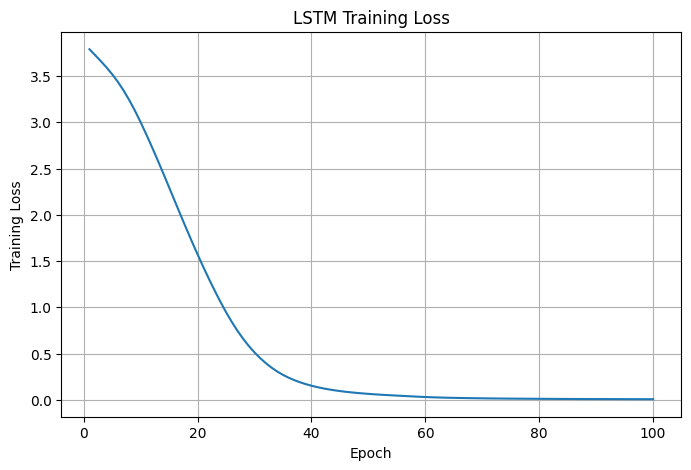

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS + 1), lstm_losses)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("LSTM Training Loss")
plt.grid(True)
plt.show()


In [15]:
# GRU Language Model

class GRULanguageModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.gru = nn.GRU(
            input_size=embed_dim,
            hidden_size=hidden_size,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x):
        # Embedding
        embedded = self.embedding(x)

        # GRU
        output, _ = self.gru(embedded)

        # Final time-step
        last_output = output[:, -1, :]

        # Vocabulary logits
        logits = self.fc(last_output)

        return logits


# Create GRU model
gru_model = GRULanguageModel(
    vocab_size=len(vocab),
    embed_dim=EMBED_DIM,
    hidden_size=HIDDEN_SIZE
)

print(gru_model)

GRULanguageModel(
  (embedding): Embedding(44, 32)
  (gru): GRU(32, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=44, bias=True)
)


In [16]:
# Validate GRU forward pass

with torch.no_grad():
    gru_output = gru_model(X[:2])

# Count trainable parameters
gru_params = sum(
    p.numel() for p in gru_model.parameters() if p.requires_grad
)

print("Input shape        :", X[:2].shape)
print("Output shape       :", gru_output.shape)
print("Vocabulary size    :", len(vocab))
print("Trainable params   :", gru_params)

print("\nLSTM parameters    :", lstm_params)
print("GRU parameters     :", gru_params)

Input shape        : torch.Size([2, 5])
Output shape       : torch.Size([2, 44])
Vocabulary size    : 44
Trainable params   : 23084

LSTM parameters    : 29356
GRU parameters     : 23084


In [17]:
# Train the GRU model

gru_losses = []
gru_epoch_times = []

gru_optimizer = optim.Adam(
    gru_model.parameters(),
    lr=LEARNING_RATE
)

gru_model.train()

for epoch in range(EPOCHS):
    epoch_start = time.time()

    # Forward pass
    logits = gru_model(X)

    # Calculate loss
    loss = criterion(logits, y)

    # Backpropagation
    gru_optimizer.zero_grad()
    loss.backward()
    gru_optimizer.step()

    # Record results
    epoch_time = time.time() - epoch_start

    gru_losses.append(loss.item())
    gru_epoch_times.append(epoch_time)

    # Print progress
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(
            f"Epoch {epoch + 1:3d}/{EPOCHS} | "
            f"Loss: {loss.item():.4f} | "
            f"Time: {epoch_time:.4f}s"
        )

print("\nGRU training completed.")
print(f"Initial loss : {gru_losses[0]:.4f}")
print(f"Final loss   : {gru_losses[-1]:.4f}")
print(f"Total time   : {sum(gru_epoch_times):.2f}s")
print(f"Avg/epoch    : {sum(gru_epoch_times) / EPOCHS:.4f}s")


Epoch   1/100 | Loss: 3.7918 | Time: 0.0080s
Epoch  10/100 | Loss: 2.6193 | Time: 0.0060s
Epoch  20/100 | Loss: 1.0506 | Time: 0.0060s
Epoch  30/100 | Loss: 0.2769 | Time: 0.0060s
Epoch  40/100 | Loss: 0.0905 | Time: 0.0070s
Epoch  50/100 | Loss: 0.0325 | Time: 0.0060s
Epoch  60/100 | Loss: 0.0161 | Time: 0.0050s
Epoch  70/100 | Loss: 0.0107 | Time: 0.0070s
Epoch  80/100 | Loss: 0.0082 | Time: 0.0070s
Epoch  90/100 | Loss: 0.0067 | Time: 0.0060s
Epoch 100/100 | Loss: 0.0057 | Time: 0.0060s

GRU training completed.
Initial loss : 3.7918
Final loss   : 0.0057
Total time   : 0.61s
Avg/epoch    : 0.0061s


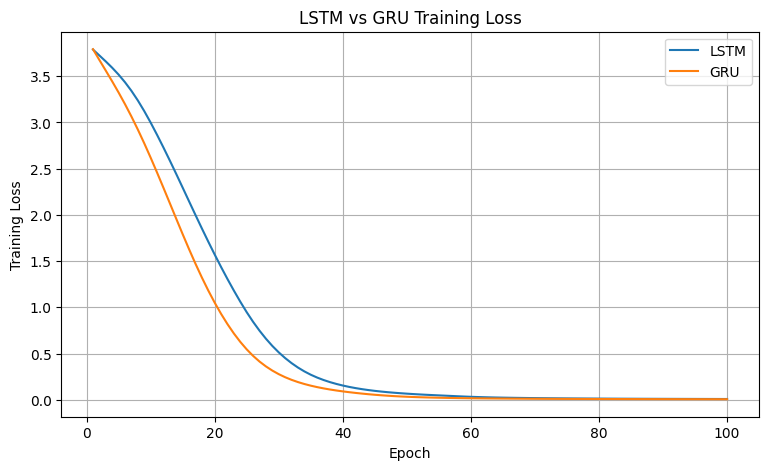

In [18]:
plt.figure(figsize=(9, 5))

plt.plot(
    range(1, EPOCHS + 1),
    lstm_losses,
    label="LSTM"
)

plt.plot(
    range(1, EPOCHS + 1),
    gru_losses,
    label="GRU"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("LSTM vs GRU Training Loss")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
def generate_text(model, seed_text, num_words=5):
    model.eval()

    words = seed_text.lower().split()
    
    with torch.no_grad():
        for _ in range(num_words):
            # Use the last SEQ_LEN words
            context_words = words[-SEQ_LEN:]

            # Convert words to token IDs
            context_ids = [
                word_to_id[word] for word in context_words
            ]

            # Create input tensor
            input_tensor = torch.tensor(
                [context_ids],
                dtype=torch.long
            )

            # Predict next word
            logits = model(input_tensor)
            predicted_id = torch.argmax(logits, dim=1).item()

            # Convert ID back to word
            predicted_word = id_to_word[predicted_id]

            words.append(predicted_word)

    return " ".join(words)


# Same seed for both models
seed_text = "the model receives a sequence"

lstm_generated = generate_text(
    lstm_model,
    seed_text,
    num_words=5
)

gru_generated = generate_text(
    gru_model,
    seed_text,
    num_words=5
)

print("Seed:")
print(seed_text)

print("\nLSTM generated text:")
print(lstm_generated)

print("\nGRU generated text:")
print(gru_generated)

Seed:
the model receives a sequence

LSTM generated text:
the model receives a sequence of words and predicts the

GRU generated text:
the model receives a sequence of words and predicts the


In [20]:
import pandas as pd

comparison = pd.DataFrame({
    "Metric": [
        "Trainable Parameters",
        "Initial Training Loss",
        "Final Training Loss",
        "Total Training Time (s)",
        "Average Time per Epoch (s)",
        "Generated Text"
    ],
    "LSTM": [
        lstm_params,
        lstm_losses[0],
        lstm_losses[-1],
        sum(lstm_epoch_times),
        sum(lstm_epoch_times) / EPOCHS,
        lstm_generated
    ],
    "GRU": [
        gru_params,
        gru_losses[0],
        gru_losses[-1],
        sum(gru_epoch_times),
        sum(gru_epoch_times) / EPOCHS,
        gru_generated
    ]
})

print(comparison.to_string(index=False))

                    Metric                                                    LSTM                                                     GRU
      Trainable Parameters                                                   29356                                                   23084
     Initial Training Loss                                                3.788306                                                 3.79178
       Final Training Loss                                                0.008114                                                0.005737
   Total Training Time (s)                                                0.556254                                                0.614265
Average Time per Epoch (s)                                                0.005563                                                0.006143
            Generated Text the model receives a sequence of words and predicts the the model receives a sequence of words and predicts the


In [21]:
parameter_reduction = lstm_params - gru_params
parameter_reduction_percent = (
    parameter_reduction / lstm_params
) * 100

time_difference = (
    sum(gru_epoch_times) - sum(lstm_epoch_times)
)

time_difference_percent = (
    time_difference / sum(lstm_epoch_times)
) * 100

print("GRU parameter reduction:")
print(f"{parameter_reduction} parameters")
print(f"{parameter_reduction_percent:.2f}% fewer than LSTM")

print("\nTraining-time difference:")
print(f"{time_difference:.6f} seconds")
print(f"{time_difference_percent:.2f}% slower than LSTM")

print("\nFinal loss difference:")
print(f"{lstm_losses[-1] - gru_losses[-1]:.6f}")


GRU parameter reduction:
6272 parameters
21.37% fewer than LSTM

Training-time difference:
0.058010 seconds
10.43% slower than LSTM

Final loss difference:
0.002377
